In [ ]:
!hostname

cn067.delta.ncsa.illinois.edu


In [2]:
import scanpy as sc
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
import decoupler

/projects/bgdb/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/projects/bgdb/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/projects/bgdb/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [13]:
import os
os.chdir('/projects/bgdb/asachan/bioinfo_analysis/human_SKM_multimodal_analysis/py_scripts')  # directory containing utils.py
import sys
import logging
import warnings

export_dir = "/projects/bgdb/asachan/datasets/SKM_ageing_human/atac_objects/atac_fiber"

In [4]:
from utils import *

In [8]:
adata_infile_fiber = '/projects/bgdb/asachan/datasets/SKM_ageing_human/rna_objects/Myofiber_scsn_RNA.h5ad'
adata_female_downsampled = '/projects/bgdb/asachan/datasets/SKM_ageing_human/rna_objects/type2fibers_female_downsampled_aucell.h5ad'
adata_male_downsampled = '/projects/bgdb/asachan/datasets/SKM_ageing_human/rna_objects/type2fibers_male_downsampled.h5ad'
out_tmp = '/projects/bgdb/asachan/datasets/SKM_ageing_human/tmp'

# Myofiber analysis

In [9]:
adata_myofibers = sc.read_h5ad(adata_infile_fiber)
#string has II in it - subset to type 2 fibers
adata_type2 = adata_myofibers[adata_myofibers.obs['Annotation'].str.contains('II')].copy()

### Downsample to people who have the highest signal for DNA repair activity

In [ ]:
adata_female_downsampled = adata_type2[adata_type2.obs['sample'].isin(['P26', 'YM2', 'OM6', 'OM8'])].copy()
adata_male_downsampled = adata_type2[adata_type2.obs['sample'].isin(['P13', 'P5', 'OM5', 'OM7'])].copy()

In [ ]:
# count the number of cells in each age
display(adata_female_downsampled.obs['sample'].value_counts())

In [ ]:
# count the number of cells in each age
display(adata_male_downsampled.obs['sample'].value_counts())

In [ ]:
# save type 2 fibers male and female downsampled
out_dir = '/projects/bgdb/asachan/datasets/SKM_ageing_human'
adata_female_downsampled.write_h5ad(os.path.join(out_dir, 'type2fibers_female_downsampled.h5ad'))
adata_male_downsampled.write_h5ad(os.path.join(out_dir, 'type2fibers_male_downsampled.h5ad'))

### Viz

In [10]:
adata_female = adata_type2[adata_type2.obs['Sex'].isin(['Female'])].copy()

In [11]:
adata_female.obs['Annotation'].value_counts()

Annotation
Type II        17625
ENOX1+ (II)     3985
ID1+ (II)       1955
SAA2+ (II)      1672
DCLK1+ (II)      469
TNNT2+ (II)       25
Name: count, dtype: int64

In [12]:
adata_female.obs['sample'].value_counts()

sample
OM9    15317
YM2     4145
OM6     3436
OM8      783
OM2      583
P21      548
P3       413
OM1      256
P27      128
P26      122
Name: count, dtype: int64

## Keep the samples in rna and atac common

In [14]:
atac_adata = sc.read_h5ad(f"{export_dir}/atac_peaks_female_type2.h5ad")

In [18]:
# keep the common samples
common_samples = set(adata_female.obs['sample']).intersection(set(atac_adata.obs['sample']))
adata_female = adata_female[adata_female.obs['sample'].isin(common_samples)].copy()
atac_adata = atac_adata[atac_adata.obs['sample'].isin(common_samples)].copy()


In [19]:
adata_female.obs['sample'].value_counts()

sample
OM9    15317
YM2     4145
OM6     3436
OM2      583
P21      548
P26      122
Name: count, dtype: int64

In [20]:
atac_adata.obs['sample'].value_counts()

sample
YM2    5250
OM9    4575
P26    2001
OM2    1148
OM6     243
P21      24
Name: count, dtype: int64

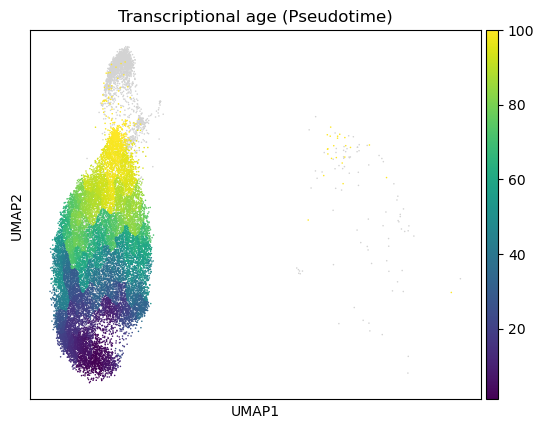

In [21]:
sc.pl.umap(adata_female, color=['Pseudotime'], title='Transcriptional age (Pseudotime)')

In [22]:
# write to file
adata_female.write_h5ad(f"{export_dir}/rna_female_type2.h5ad")
atac_adata.write_h5ad(f"{export_dir}/atac_female_type2.h5ad")


## Molecular age (pseudotime based) of each sample

/projects/bgdb/asachan/bioinfo_analysis/human_SKM_multimodal_analysis/py_scripts/utils.py:103: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_summary_df_all_annotations = obs_df_valid_pt.groupby(['sample', annotation_col]).agg(


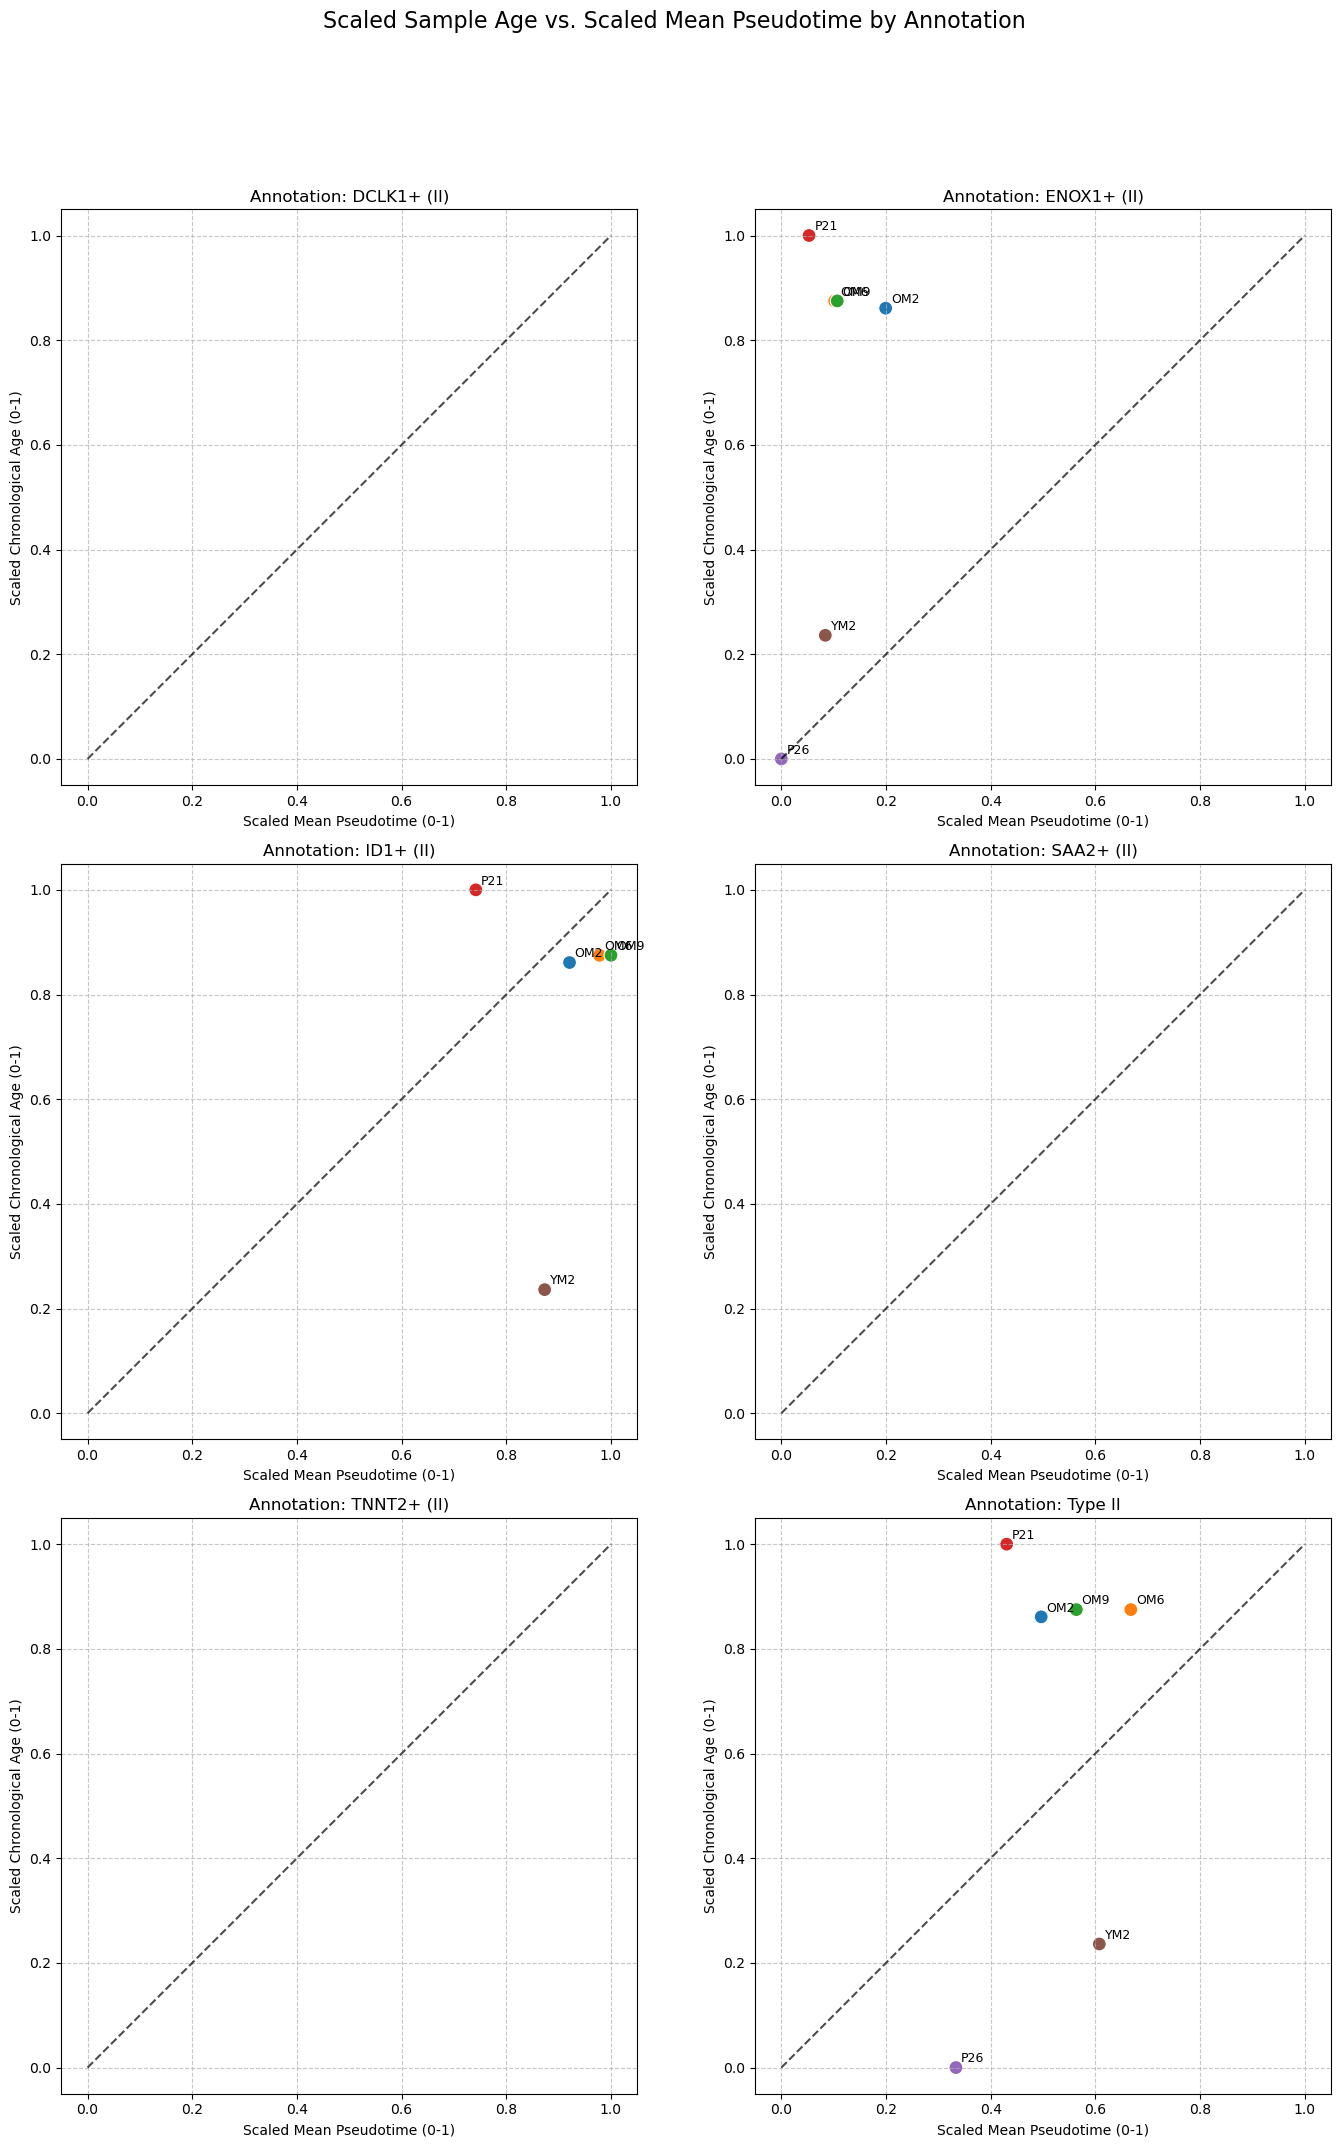

In [23]:
fig_by_annotation, summary_df_all = plot_age_vs_pseudotime_by_annotation(
    adata_female,
    annotation_col='Annotation', # Make sure this column name is correct
    point_size=100,
    n_subplot_cols=2 # Or 1 if you only have 'Type I' and 'Type II' and want them stacked
)

# AUCell activity scoring of specific pathways

In [24]:
# load geneset of interest
geneset_dir = '/projects/bgdb/asachan/datasets/gene_sets'
# geneset_gmt = ["/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/GOBP_FATTY_ACID_BETA_OXIDATION.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_CITRATE_CYCLE_TCA_CYCLE.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_GLYCOLYSIS_GLUCONEOGENESIS.v2024.1.Hs.gmt",
#                "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_OXIDATIVE_PHOSPHORYLATION.v2024.1.Hs.gmt","/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM.v2024.1.Hs.gmt","/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM.v2024.1.Hs.gmt"]
# geneset_df = gmt_to_decoupler_multiple_pathways(geneset_gmt)
geneset_gmt = [os.path.join(geneset_dir, 'human/DNA_repair/GOBP_DNA_REPAIR.v2024.1.Hs.gmt'), os.path.join(geneset_dir, 'human/DNA_damage_response/GOBP_DNA_DAMAGE_RESPONSE.v2024.1.Hs.gmt'), 
               os.path.join(geneset_dir, 'human/DNA_repair/REACTOME_DNA_REPAIR.v2024.1.Hs.gmt'), os.path.join(geneset_dir, 'human/DNA_repair/HALLMARK_DNA_REPAIR.v2024.1.Hs.gmt')]
geneset_df = gmt_to_decoupler_multiple_pathways(geneset_gmt, geneset_name='source', genesymbol_name='target')
# get the number of rows in each unique geneset
geneset_size = geneset_df['source'].value_counts()
display(geneset_size)
display(geneset_df)
# custom_atrophy_pathway = ["UBB","UBC","FBXO32","TRIM63","MDM2","FBXO30","CAMK2B","TIE1","PSMA1","PSMA2","PSMA3","PSMA4","PSMA5","PSMA6","PSMA7","PSMB1","PSMB2","PSMB3","PSMB4","FBXO21","FBXO31","NEDD4","UBE2B","UBE2G1","UBE2J1","CTSL","CTSV","BNIP3","DEPP1","GABARAPL1","MAP1LC3","RETREG1","SQSTM1","CAPN1","CAPN2","ATF4","FOXO1","FOXO3A","HDAC9","RUNX1","AMPD3","CHRNA1","CDKN1A"]
# geneset_df = pd.DataFrame({'geneset': "Atrophy Pathway (PMID: 31325479)", 'genesymbol': custom_atrophy_pathway})
# geneset_df


source
GOBP_DNA_DAMAGE_RESPONSE    906
GOBP_DNA_REPAIR             615
REACTOME_DNA_REPAIR         332
HALLMARK_DNA_REPAIR         150
Name: count, dtype: int64

,source,target
0,GOBP_DNA_REPAIR,ABL1
1,GOBP_DNA_REPAIR,ABRAXAS1
2,GOBP_DNA_REPAIR,ACTB
3,GOBP_DNA_REPAIR,ACTL6A
4,GOBP_DNA_REPAIR,ACTL6B
...,...,...
1998,HALLMARK_DNA_REPAIR,VPS37B
1999,HALLMARK_DNA_REPAIR,VPS37D
2000,HALLMARK_DNA_REPAIR,XPC
2001,HALLMARK_DNA_REPAIR,ZNF707


In [25]:
%%time
decoupler.mt.aucell(
    adata_female,
    geneset_df,
    raw=False,
    verbose=True
)

2026-04-15 23:10:28 | [INFO] aucell - Running aucell
2026-04-15 23:10:28 | [INFO] Extracted omics mat with 24151 rows (observations) and 48355 columns (features)
2026-04-15 23:10:28 | [WARNING] 7654 features of mat are empty, they will be removed
2026-04-15 23:10:29 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026-04-15 23:10:29 | [INFO] Network has 1030 unique features and 4 unique sources
2026-04-15 23:10:29 | [INFO] aucell - calculating 4 AUCs for 40701 targets across 24151 observations, categorizing features at rank=2036


  0%|          | 0/24151 [00:00<?, ?it/s]

2026-04-15 23:10:48 | [INFO] aucell - done


CPU times: user 18.9 s, sys: 826 ms, total: 19.7 s
Wall time: 20.2 s


In [26]:
dna_damage_pathways = [
    "GOBP_DNA_REPAIR",
    "GOBP_DNA_DAMAGE_RESPONSE",
    "REACTOME_DNA_REPAIR",
    "HALLMARK_DNA_REPAIR"
]
# metabolic_pathways = [
#     "GOBP_FATTY_ACID_BETA_OXIDATION",
#     "KEGG_CITRATE_CYCLE_TCA_CYCLE",
#     "KEGG_GLYCOLYSIS_GLUCONEOGENESIS",
#     "KEGG_OXIDATIVE_PHOSPHORYLATION",
#     "REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM",
#     "REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM"
# ]

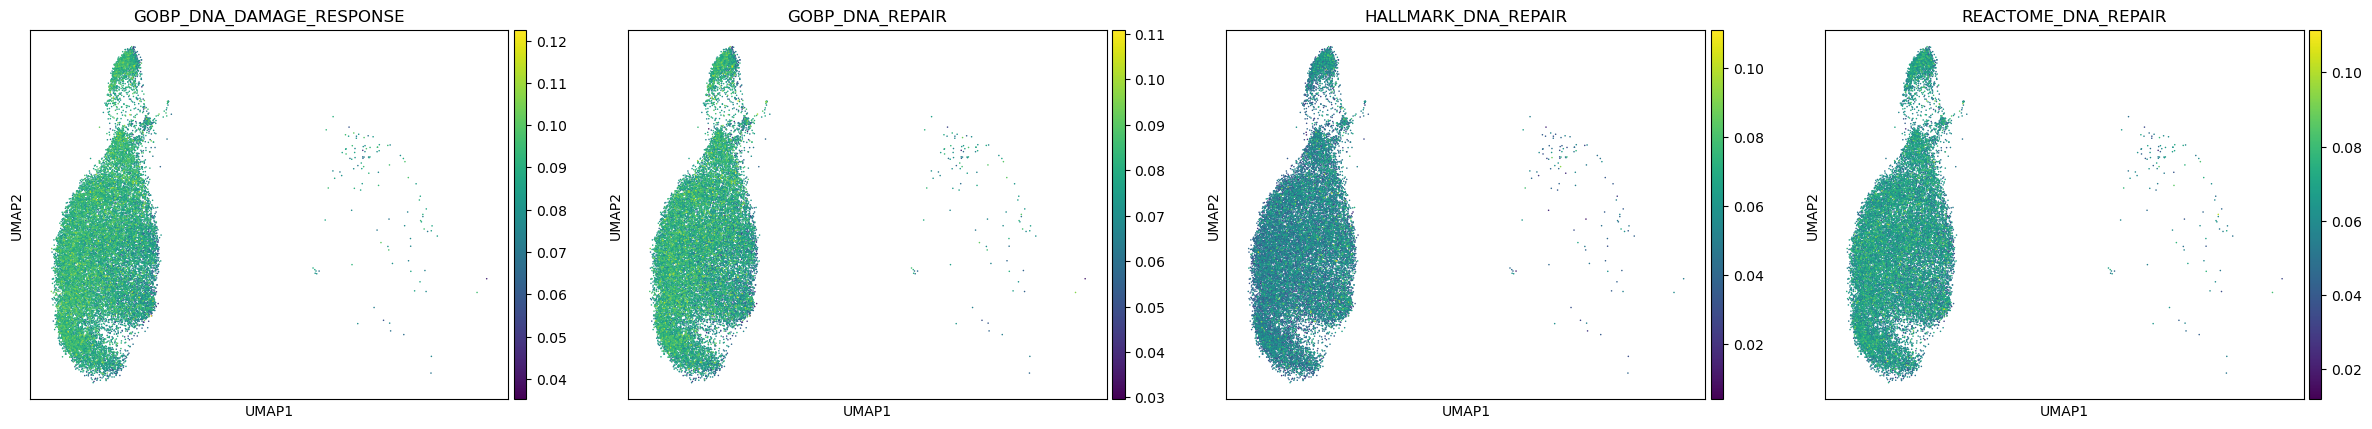

In [27]:
# Copy AUCell scores to obs so you can use them as color
aucell_df = adata_female.obsm['score_aucell']
for col in aucell_df.columns:
    adata_female.obs[col] = aucell_df[col].values

# Then plot on UMAP
sc.pl.umap(adata_female, color=aucell_df.columns.tolist())

In [28]:
# save the adata_female_downsampled with the AUCell scores
out_dir = '/projects/bgdb/asachan/datasets/SKM_ageing_human'
adata_female.write_h5ad(os.path.join(out_dir, 'type2fibers_female_aucell.h5ad'))

### Plot samples ordered by score to select outliers for bar-plot comparitive analysis between cohorts

In [29]:
# get a df of sample ID, sample score per cell type and age
sample_scores = adata_female.obs[['sample','age', 'Annotation']+dna_damage_pathways].copy()
# average scores per sample and group by Annotation
sample_scores_avg = sample_scores.groupby(['sample', 'Annotation']).mean().reset_index()
sample_scores_avg.head()

/tmp/ipykernel_225689/2055940568.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_scores_avg = sample_scores.groupby(['sample', 'Annotation']).mean().reset_index()


,sample,Annotation,age,GOBP_DNA_REPAIR,GOBP_DNA_DAMAGE_RESPONSE,REACTOME_DNA_REPAIR,HALLMARK_DNA_REPAIR
0,OM2,Type II,79.0,0.063299,0.074257,0.052370,0.038438
1,OM2,DCLK1+ (II),79.0,0.064880,0.074690,0.055500,0.043765
2,OM2,ENOX1+ (II),79.0,0.056648,0.067131,0.045278,0.033317
3,OM2,ID1+ (II),79.0,0.065304,0.075898,0.050923,0.039608
4,OM2,SAA2+ (II),79.0,0.066043,0.075636,0.056553,0.039390


## Plots wrt age

In [30]:
# Use cell-level data directly from adata.obs
cell_level_scores_df = adata_female.obs[['sample', 'age', 'Annotation', 'Pseudotime'] + dna_damage_pathways].copy()
# geneset_sizes_data = {
#     'KEGG_OXIDATIVE_PHOSPHORYLATION': 132,
#     'GOBP_FATTY_ACID_BETA_OXIDATION': 75,
#     'KEGG_GLYCOLYSIS_GLUCONEOGENESIS': 62,
#     'KEGG_CITRATE_CYCLE_TCA_CYCLE': 31,
#     'REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM': 21,
#     'REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM': 14
# }
geneset_sizes_data = {
    'GOBP_DNA_REPAIR': 615,
    'GOBP_DNA_DAMAGE_RESPONSE': 906,
    'REACTOME_DNA_REPAIR': 332,
    'HALLMARK_DNA_REPAIR': 150
}
geneset_sizes_series = pd.Series(geneset_sizes_data)

2026-04-15 23:16:11 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/projects/bgdb/asachan/bioinfo_analysis/human_SKM_multimodal_analysis/py_scripts/utils.py:1190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  violin = sns.violinplot(
2026-04-15 23:16:12 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-15 23:16:12 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-15 23:16:12 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-15 23:16:12 | [INFO] Using ca

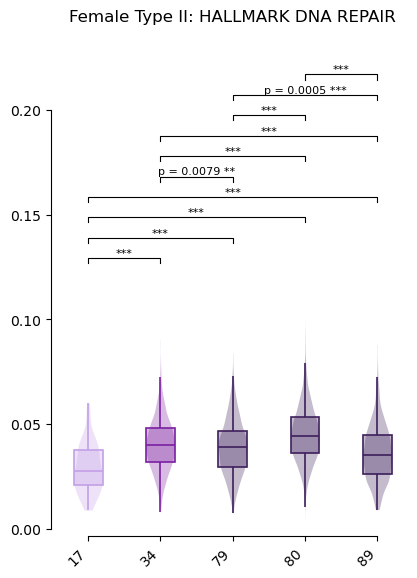

<Figure size 640x480 with 0 Axes>

In [38]:
plot_data = cell_level_scores_df.copy()
plot_data['age'] = plot_data['age'].astype(str)

custom_colors = {
    '17': '#C4A0E7',
    '34': '#7B1FA2',
    '79': '#3D1F5C',
    '80': '#3D1F5C',
    '89': '#3D1F5C'
}

# custom_colors = {
#     '38': '#87CEEB',  # Sky blue
#     '45': '#4682B4',  # Steel blue
#     '82': '#191970'  # Midnight blue,
# }

fig = plot_violin_box_combo(
    data=plot_data,
    x_var='age',
    y_var='HALLMARK_DNA_REPAIR',
    title='Female Type II: HALLMARK DNA REPAIR',
    x_ticks=['17','34','79','80','89'],
    palette=custom_colors,
    rotation=45,
    show_scatter=False
)

# Display the plot
from IPython.display import display
display(fig)
# save as pdf 
#fig.savefig('/ocean/projects/cis240075p/asachan/datasets/senescence_datasets/mouse_liver/figures/cellage_scores.pdf', bbox_inches='tight')

### filter out samples that are adding noise/not contributing to the trend while saving cells in both atac and rna adatas
#### P21 in females

In [ ]:
# remove P21 from adata_female
adata_female = adata_female[adata_female.obs['sample'] != 'P21'].copy()
# remove P21 from adata_atac
atac_adata = atac_adata[atac_adata.obs['sample'] != 'P21'].copy()
# save the filtered adatas
adata_female.write_h5ad(f"{export_dir}/rna_female_type2_noP21.h5ad")
atac_adata.write_h5ad(f"{export_dir}/atac_female_type2_noP21.h5ad")


## Plots wrt pseudotime

2026-04-15 15:19:04 | [INFO] Animation.save using <class 'matplotlib.animation.PillowWriter'>


⚠ FFmpeg not found - will use GIF format instead

Starting animation creation...
Figure created with 1 animated lines
Creating animation with 200 frames at 30 fps...
Saving as GIF to pathway_animation.gif...
✓ GIF saved successfully!


/projects/bgdb/asachan/bioinfo_analysis/human_SKM_multimodal_analysis/py_scripts/pathway_animation.gif


Animation saved! Click the link above to download.

Animation creation complete!


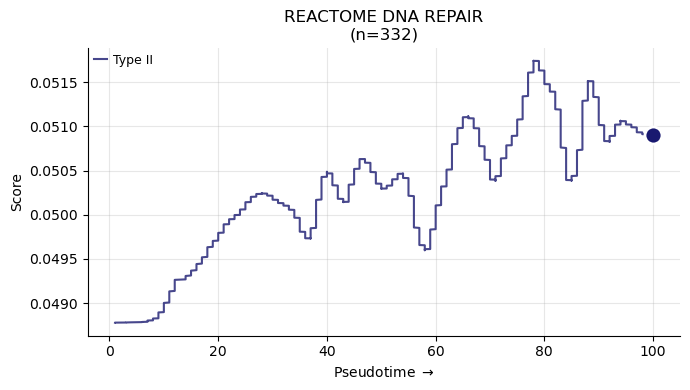

In [50]:
# ====== USAGE ======
plot_colors = {'Type II': '#191970'}
legend_labels = {'Type II': 'Type II'}

# First, let's check if ffmpeg is available
import subprocess
try:
    result = subprocess.run(['ffmpeg', '-version'], 
                          capture_output=True, text=True, timeout=5)
    print("✓ FFmpeg is installed")
    use_gif_format = False
except:
    print("⚠ FFmpeg not found - will use GIF format instead")
    use_gif_format = True

print()


# Your list of score columns
score_cols_to_plot = ['REACTOME_DNA_REPAIR']

# Create animation
anim_result = create_animated_pathway_plot(
    df_cell_level=cell_level_scores_df,
    score_cols=score_cols_to_plot,
    pseudotime_key='Pseudotime',
    group_by_key='Annotation',
    smoothing_method='gaussian',
    smoothing_strength=120.0,  # Smoother lines
    geneset_sizes=geneset_sizes_series,
    groups_to_plot=['Type II'],
    colors_dict=plot_colors,
    legend_labels_map=legend_labels,
    n_subplot_cols=1,
    figsize_per_subplot=(7, 4),
    nframes=200,  # More frames = smoother
    fps=30,
    dot_size=150,
    output_file='pathway_animation.mp4',
    use_gif=use_gif_format  # Will auto-detect
)

print("\n" + "=" * 60)
print("Animation creation complete!")
print("=" * 60)

In [ ]:
# # Colors for 'Type I' and 'Type II'
# plot_colors = {'Type I': '#F08080', 'Type II': '#191970'}
# legend_labels = {'Type I': 'Type I', 'Type II': 'Type II'}

# plot_multi_smoothed_lines_from_df(
#     df_cell_level=cell_level_scores_df,
#     score_cols=score_cols_to_plot,
#     pseudotime_key='Pseudotime',
#     group_by_key='Annotation',
#     smoothing_method='gaussian',          # Specify method
#     smoothing_strength=70.0,             # Fraction for LOWESS (e.g., 0.05 to 0.2)
#     geneset_sizes=geneset_sizes_series,
#     groups_to_plot=['Type I', 'Type II'],
#     colors_dict=plot_colors,
#     legend_labels_map=legend_labels,
#     n_subplot_cols=2,
#     figsize_per_subplot=(7, 4),
#     common_xlabel=r"Pseudotime $\rightarrow$",
#     common_ylabel="Score",
#     common_ylim=None, common_xticks_list=None, common_yticks_list=None,
#     common_legend_loc=(0.02, 0.85), common_line_kwargs={'linewidth': 1.0},
#     main_figure_title=None,
#     debug_prints_for_subp_plot_func=False
# )


# ATAC data load

In [2]:
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
from scipy.io import mmread
from scipy.sparse import csr_matrix
import os

/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-p

In [3]:
export_dir = "/projects/bgdb/asachan/datasets/SKM_ageing_human/atac_objects/atac_fiber"

# ═══════════════════════════════════════════
# A. Build ATAC AnnData
# ═══════════════════════════════════════════
counts = csr_matrix(mmread(f"{export_dir}/atac_counts.mtx").T)  # peaks×cells → cells×peaks
peaks  = open(f"{export_dir}/peaks.tsv").read().strip().split("\n")
bcs    = open(f"{export_dir}/barcodes.tsv").read().strip().split("\n")

adata_atac = ad.AnnData(X=counts, obs=pd.DataFrame(index=bcs), var=pd.DataFrame(index=peaks))

# Metadata
meta = pd.read_csv(f"{export_dir}/metadata.csv", index_col=0)
adata_atac.obs = meta.reindex(adata_atac.obs_names)

# Embeddings
for f in os.listdir(export_dir):
    if f.startswith("embedding_") and f.endswith(".tsv"):
        name = f.replace("embedding_", "").replace(".tsv", "")
        emb = pd.read_csv(f"{export_dir}/{f}", sep="\t", index_col=0)
        adata_atac.obsm[f"X_{name}"] = emb.reindex(adata_atac.obs_names).values
        print(f"  Added X_{name}: {adata_atac.obsm[f'X_{name}'].shape}")

adata_atac.write(f"{export_dir}/atac_peaks.h5ad")
print(f"ATAC AnnData: {adata_atac.shape}")

ATAC AnnData: (65380, 265003)


In [14]:
adata_atac = sc.read_h5ad(f"{export_dir}/atac_peaks.h5ad")

In [15]:
## subset to type2 female fibers
adata_atac = adata_atac[adata_atac.obs['Annotation'].str.contains('II')].copy()
adata_atac.obs


,Sample,TSSEnrichment,ReadsInTSS,ReadsInPromoter,ReadsInBlacklist,PromoterRatio,PassQC,NucleosomeRatio,nMultiFrags,nMonoFrags,...,ReadsInPeaks,FRIP,fiber_class_1_anno,Annotation,UMAP_1,UMAP_2,fiber_class_anno,country,age,Sex
Human_Muscle_210209_Normal_3#Human_Muscle_210209_Normal_3_BC04672_N02,Human_Muscle_210209_Normal_3,8.543,5548,5963,311,0.106349,1,0.651936,2826,16971,...,17323,0.309063,Type IIx,SAA2+ (II),4.414549,-7.525551,Type IIx,China,79,Male
Human_Muscle_210209_Normal_3#Human_Muscle_210209_Normal_3_BC06312_N03,Human_Muscle_210209_Normal_3,12.623,10276,11016,347,0.198408,1,0.481140,1772,18743,...,28162,0.507277,Hybrid IIx/IIa,SAA2+ (II),3.379762,-5.507559,Hybrid IIx/IIa,China,79,Male
Human_Muscle_210209_Normal_3#Human_Muscle_210209_Normal_3_BC05992_N03,Human_Muscle_210209_Normal_3,13.030,10456,10636,323,0.203685,1,0.500862,2148,17396,...,32705,0.626341,Unknown II-subtype,SAA2+ (II),5.594536,-6.771801,Unknown II-subtype,China,79,Male
Human_Muscle_210209_Normal_3#Human_Muscle_210209_Normal_3_BC04567_N02,Human_Muscle_210209_Normal_3,8.262,5019,5350,308,0.102644,1,0.328355,564,19619,...,14483,0.277931,Type IIa,ID1+ (II),1.825466,-4.546646,Type IIa,China,79,Male
Human_Muscle_210209_Normal_3#Human_Muscle_210209_Normal_3_BC06345_N03,Human_Muscle_210209_Normal_3,14.850,11286,11596,267,0.237535,1,0.463720,1869,16676,...,30708,0.629056,Type IIx,SAA2+ (II),4.113221,-7.013335,Type IIx,China,79,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Human_Muscle_200929_Normal_3#Human_Muscle_200929_Normal_3_BC4846_N01,Human_Muscle_200929_Normal_3,13.201,2160,2277,42,0.280764,1,0.028666,0,3942,...,6754,0.833416,Type IIx,ID1+ (II),3.593245,-5.417366,Type IIx,China,80,Female
Human_Muscle_200929_Normal_3#Human_Muscle_200929_Normal_3_BC4840_N01,Human_Muscle_200929_Normal_3,11.059,1709,1784,36,0.220628,1,0.468046,117,2754,...,5451,0.675800,Type IIx,Type II,6.563418,1.511425,Type IIx,China,80,Female
Human_Muscle_200929_Normal_3#Human_Muscle_200929_Normal_3_BC4869_N01,Human_Muscle_200929_Normal_3,12.034,1969,2053,44,0.258499,1,0.046653,1,3794,...,6106,0.769211,Type IIa,ID1+ (II),3.193637,-2.000290,Type IIa,China,80,Female
Human_Muscle_200929_Normal_3#Human_Muscle_200929_Normal_3_BC4918_N01,Human_Muscle_200929_Normal_3,10.024,1544,1748,63,0.226660,1,0.010217,3,3817,...,5107,0.662902,Type IIx,SAA2+ (II),3.437193,-4.520675,Type IIx,China,80,Female


In [16]:
adata_atac_sex = adata_atac[adata_atac.obs['Sex'].isin(['Female'])].copy()

In [18]:
adata_atac_sex.obs['sample'].value_counts()

YM2    5250
OM9    4575
P26    2001
OM3    1890
OM2    1148
OM6     243
P21      24
Name: sample, dtype: int64

In [ ]:
# write to file
adata_atac_sex.write_h5ad(f"{export_dir}/atac_peaks_female_type2.h5ad")

In [7]:
# ═══════════════════════════════════════════
# B. Barcode harmonization
# ═══════════════════════════════════════════
# ArchR barcodes: "sampleName#ACGTACGT-1"
# 10x RNA barcodes: "ACGTACGT-1" or "sampleName_ACGTACGT-1"
# Check format and strip/adjust as needed:
print("ATAC barcodes:", adata_atac.obs_names[:3].tolist())
adata_rna = sc.read_h5ad("/projects/bgdb/asachan/datasets/SKM_ageing_human/rna_objects/type2fibers_female_downsampled_aucell.h5ad")
print("RNA barcodes:", adata_rna.obs_names[:3].tolist())

# Common fix for ArchR: strip "sampleName#" prefix
# adata_atac.obs_names = [bc.split("#")[1] if "#" in bc else bc for bc in adata_atac.obs_names]

# Or if RNA has sample prefixes: "F7_KO_ACGTACGT-1"
# you may need to build a mapping between the two naming conventions

common = adata_rna.obs_names.intersection(adata_atac.obs_names)
print(f"Shared barcodes: {len(common)} / RNA: {len(adata_rna)} / ATAC: {len(adata_atac)}")

ATAC barcodes: ['Human_Muscle_210209_Normal_3#Human_Muscle_210209_Normal_3_BC04139_N02', 'Human_Muscle_210209_Normal_3#Human_Muscle_210209_Normal_3_BC01476_N01', 'Human_Muscle_210209_Normal_3#Human_Muscle_210209_Normal_3_BC04672_N02']
RNA barcodes: ['CELL3027_N1_1_1_2_1_1', 'CELL142_N3_1_1_2_1_1', 'CELL1008_N1_1_1_2_1_1']
Shared barcodes: 0 / RNA: 8486 / ATAC: 65380


# MultiVI

In [ ]:
# ═══════════════════════════════════════════
# C. Build MuData
# ═══════════════════════════════════════════
import mudata as md

mdata = md.MuData({"rna": adata_rna, "atac": adata_atac})
print(mdata)

# ═══════════════════════════════════════════
# D. MultiVI
# ═══════════════════════════════════════════
import scvi

# MultiVI needs raw counts in .X for both modalities
# RNA: integer counts (not log-normalized)
# ATAC: integer/binary peak counts (already raw from ArchR)

# If RNA .X is normalized, swap in raw counts:
# adata_rna.X = adata_rna.layers["counts"].copy()

scvi.model.MULTIVI.setup_mudata(
    mdata,
    rna_layer=None,           # None = use .X
    atac_layer=None,
    batch_key="batch",        # adjust to your batch column, or remove
    modalities={
        "rna_layer": "rna",
        "atac_layer": "atac",
    },
)

model = scvi.model.MULTIVI(mdata)
model.train()

# Joint latent space
mdata.obsm["X_MultiVI"] = model.get_latent_representation()

# Imputed modalities
# mdata.obsm["atac_imputed"] = model.get_accessibility_estimates()
# mdata.obsm["rna_imputed"] = model.get_normalized_expression()

mdata.write("multiome_multivi.h5mu")
print("Done!")

# DEGs and gsea pathway analysis

#### Do size matching to get a more balanced sample size for DEG significance

In [ ]:
adata_female_downsampled.obs['age_pop'] = pd.Categorical(adata_female_downsampled.obs['age_pop'], categories=["old_pop", "young_pop"], ordered=True)

In [ ]:
bdata = adata_female_downsampled[adata_female_downsampled.obs.Annotation == "Type I"].copy()
bdata

In [ ]:
sc.tl.rank_genes_groups(bdata,
                        groupby='age_pop',
                        use_raw=False,
                        method='wilcoxon',
                        groups=["old_pop"],
                        reference='young_pop')

In [ ]:
sc.pl.rank_genes_groups(bdata, n_genes=25, sharey=False)

In [ ]:
# get deg result
result = bdata.uns['rank_genes_groups']
groups = result['names'].dtype.names
degs = pd.DataFrame(
    {group + '_' + key: result[key][group]
    for group in groups for key in ['names','scores', 'pvals','pvals_adj','logfoldchanges']})
degs.head()

In [ ]:
# subset up or down regulated genes
degs_sig = degs[degs.old_pop_pvals_adj < 0.01]
degs_up = degs_sig[degs_sig.old_pop_logfoldchanges > 0]
degs_dw = degs_sig[degs_sig.old_pop_logfoldchanges < 0]

In [ ]:
degs_up.shape

In [ ]:
degs_dw.shape

In [ ]:
enr_up = gp.enrichr(degs_up.old_pop_names,
                    gene_sets='GO_Biological_Process_2025',
                    outdir=None)

In [ ]:
enr_up.res2d

In [ ]:
# dotplot
enr_up.res2d.Term = enr_up.res2d.Term.str.split(" \(GO").str[0]
gp.dotplot(enr_up.res2d, figsize=(3,5), title="Up", cmap = plt.cm.autumn_r)
plt.show()

In [ ]:
enr_dw = gp.enrichr(degs_dw.old_pop_names,
                    gene_sets='GO_Biological_Process_2025',
                    outdir=None)

In [ ]:
enr_dw.res2d

In [ ]:
enr_dw.res2d.Term = enr_dw.res2d.Term.str.split(" \(GO").str[0]
gp.dotplot(enr_dw.res2d,
           figsize=(3,5),
           title="Down",
           cmap = plt.cm.winter_r,
           size=5)
plt.show()